# Rice Leaf Classification — CNN

Supervised image classification: จำแนกโรคใบข้าว 4 โรคและใบปกติ เพื่อช่วยคัดกรองภาพเบื้องต้นและศึกษาความแตกต่างระหว่างคลาส ไม่ยืนยันโรคในแปลง

คลาส: Rice Blast (Leaf Blast เท่านั้น), Bacterial Leaf Blight, Sheath Blight, Brown Spot, Healthy Rice Leaf

ข้อมูลมาจาก [loki4514](https://www.kaggle.com/datasets/loki4514/rice-leaf-diseases-detection) (ประกาศ Apache 2.0) และ [alamshihab075](https://www.kaggle.com/datasets/alamshihab075/rice-leaf-disease-an-images-dataset) (ประกาศ MIT). ดูรายละเอียดการอ้างอิงและข้อจำกัดใน DATASET.md

Notebook รันตามลำดับเพื่อทบทวนโมเดลที่ฝึกจริง เปิด RETRAIN เฉพาะเมื่อต้องการฝึกซ้ำ

In [1]:
from pathlib import Path
import sys,json
import numpy as np,pandas as pd
from IPython.display import display,Markdown,Image
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix
ROOT=Path.cwd().resolve()
if not (ROOT/'rice_leaf_app').is_dir():ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
from rice_leaf_app.cnn_config import CLASSES,EXAMPLES,ARTIFACTS
P=ROOT/'experiments/cnn5'
frame=pd.read_csv(P/'manifest.csv')
display(pd.DataFrame([{'label':k,'English':v[0],'Thai':v[1]} for k,v in CLASSES.items()]))
display(pd.crosstab(frame.label,frame.cnn_split))
display(pd.read_csv(ARTIFACTS/'class_counts.csv'))

,label,English,Thai
0,rice_blast,Rice Blast,โรคไหม้
1,bacterial_leaf_blight,Bacterial Leaf Blight,โรคขอบใบแห้ง
2,sheath_blight,Sheath Blight,โรคกาบใบแห้ง
3,brown_spot,Brown Spot,โรคใบจุดสีน้ำตาล
4,healthy,Healthy Rice Leaf,ใบข้าวปกติ


cnn_split,fit,test,validation
label,,,
bacterial_leaf_blight,1182,318,195
brown_spot,1229,349,207
healthy,1952,603,324
rice_blast,2235,605,377
sheath_blight,1588,353,265


,label,raw_train,raw_test,used_train,validation,used_test
0,rice_blast,4620,967,2235,377,605
1,bacterial_leaf_blight,1386,376,1182,195,318
2,sheath_blight,1853,641,1588,265,353
3,brown_spot,1480,380,1229,207,349
4,healthy,3836,994,1952,324,603


## สำรวจ เตรียม และแบ่งข้อมูล

เก็บภาพต้นทาง 5 คลาส 16,533 ไฟล์ แยก train/test ตามโฟลเดอร์ ไม่ใช้ Rice_Leaf_AUG หลังคัดภาพเสีย/ซ้ำ/เสี่ยงรั่ว ใช้ fit 8,186, validation 1,368, test 2,228 ภาพ

แก้ EXIF orientation และวางภาพโปร่งใสบนพื้นขาว ตรวจ decoded RGB hash และกลุ่มภาพคล้ายจาก pHash/RGB หลังหมุน/พลิก เก็บ manifest ที่ระบุ path, label, hash และ split เพื่อทำซ้ำ validation ประมาณ 14.3% ด้วย StratifiedGroupKFold 7 folds seed 42 ไม่มีการใช้ test ฝึกหรือจูนในรอบนี้

กลุ่มความคล้ายไม่ใช่รหัสใบจริง ชุด test เดิมเคยรายงานผลในงานทดลองก่อน จึงไม่ใช่ชุดอิสระใหม่

All dataset paths exist; similarity groups do not cross splits


,label,status,images
0,bacterial_leaf_blight,excluded,58
1,bacterial_leaf_blight,included,1704
2,brown_spot,excluded,31
3,brown_spot,included,1829
4,healthy,excluded,1882
5,healthy,included,2948
6,leaf_blast,excluded,2163
7,leaf_blast,included,3424
8,sheath_blight,excluded,288
9,sheath_blight,included,2206


Rice Blast

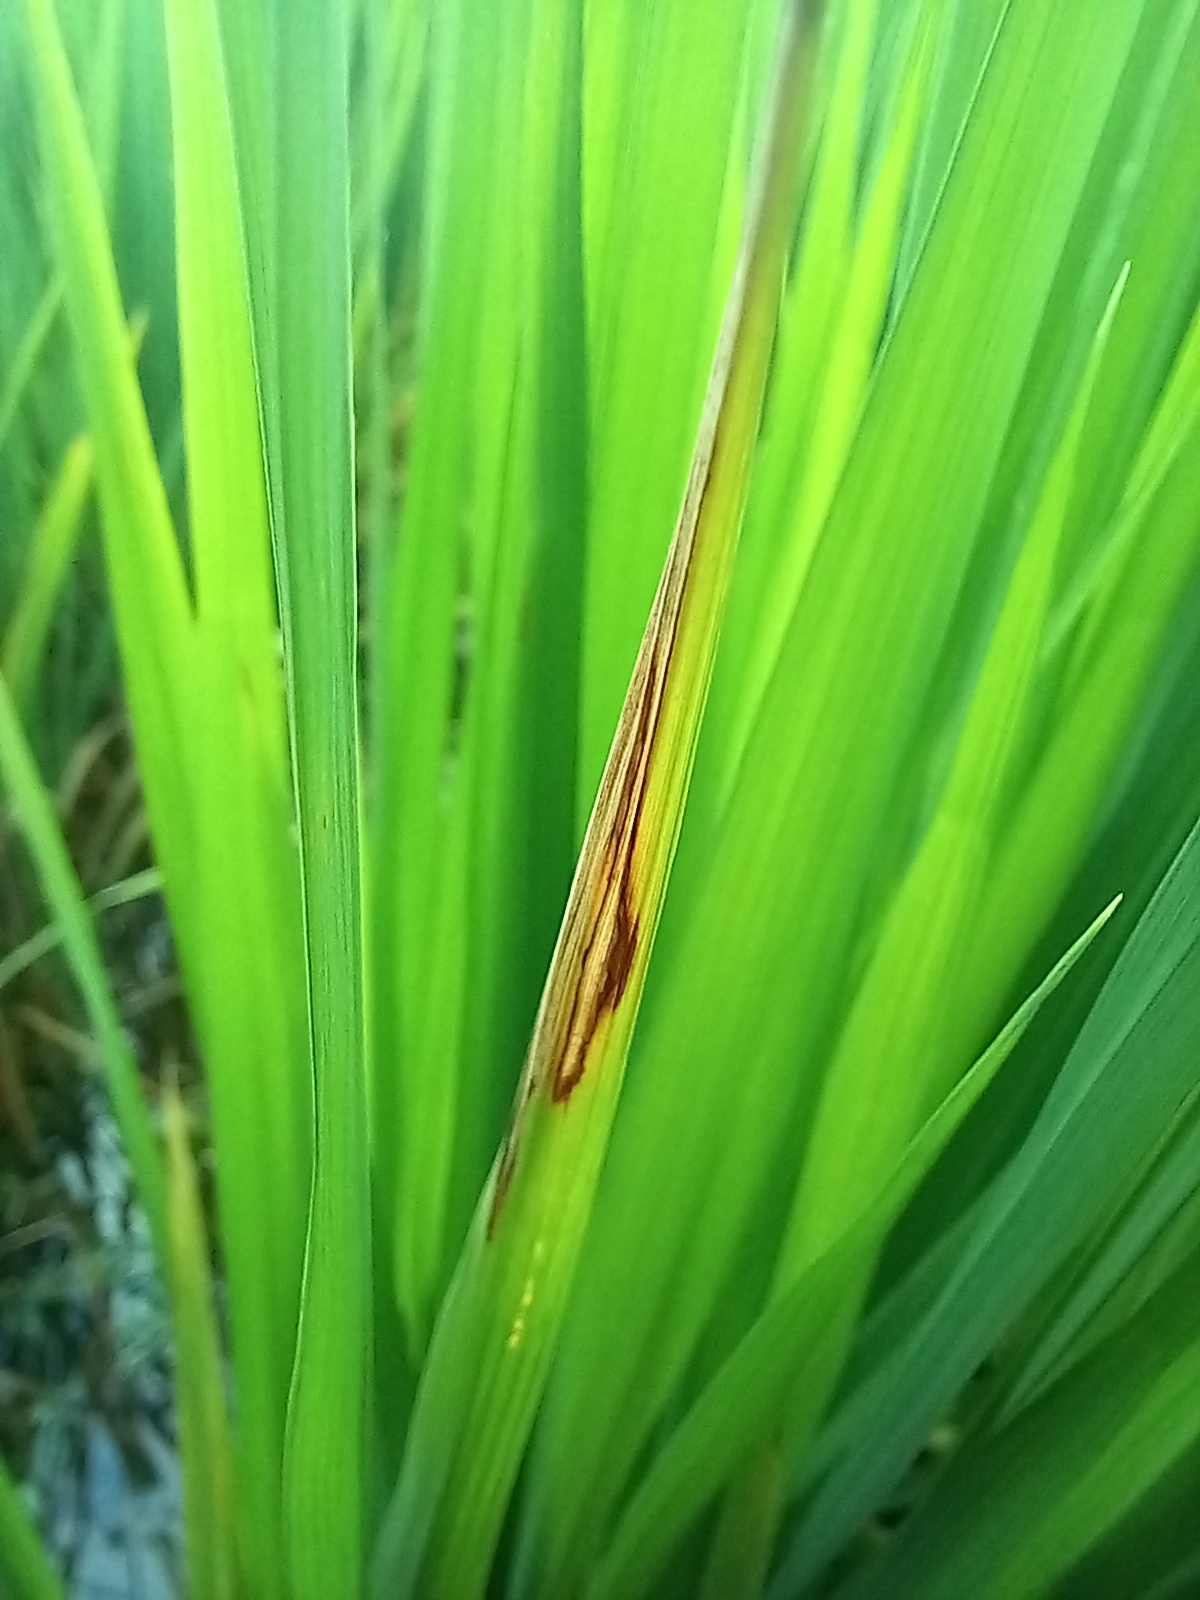

Bacterial Leaf Blight

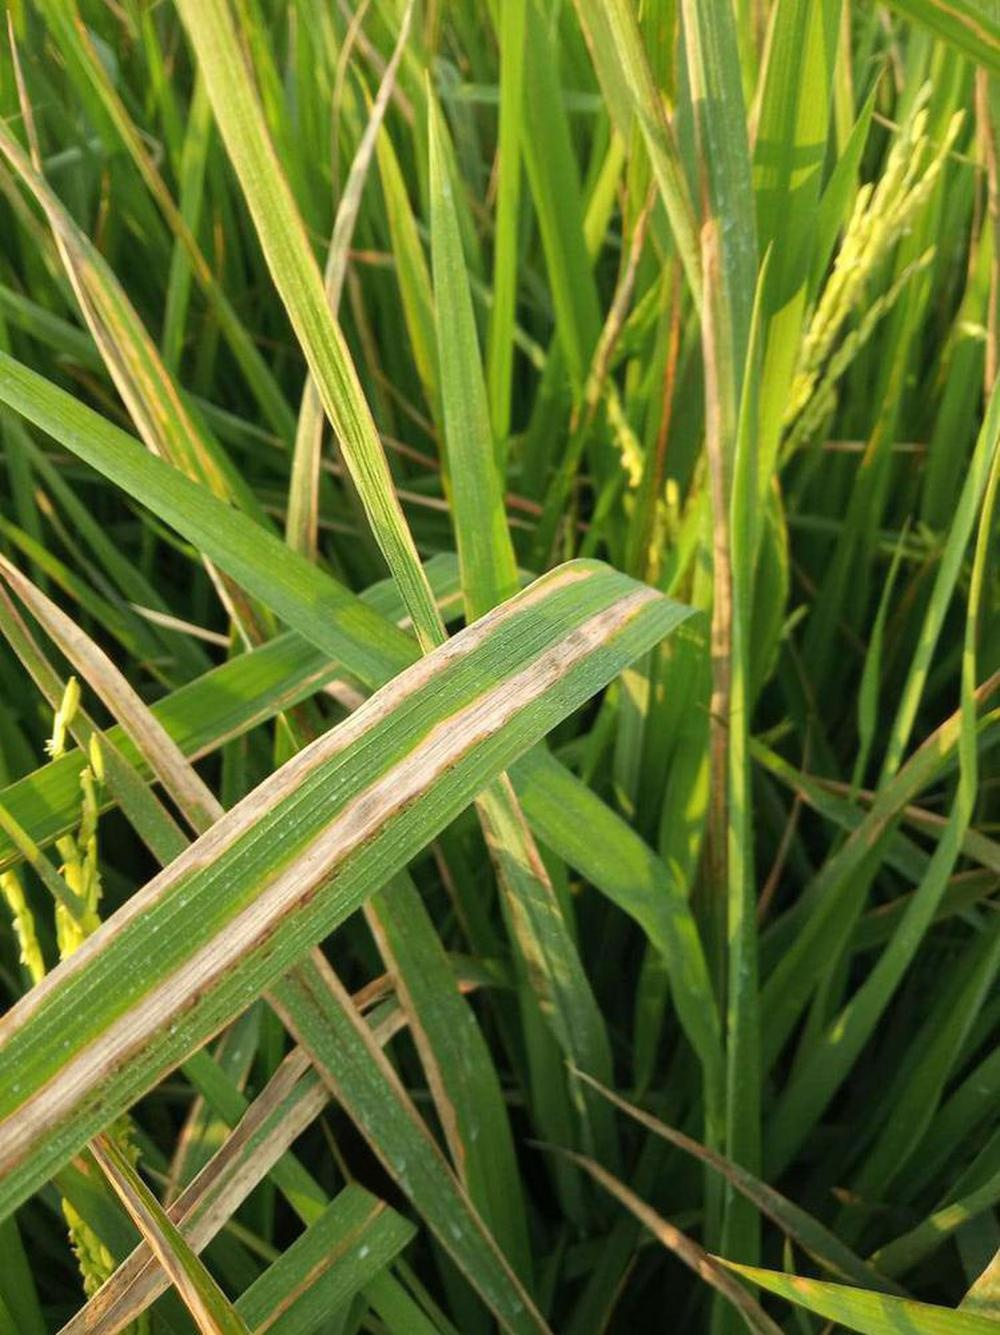

Sheath Blight

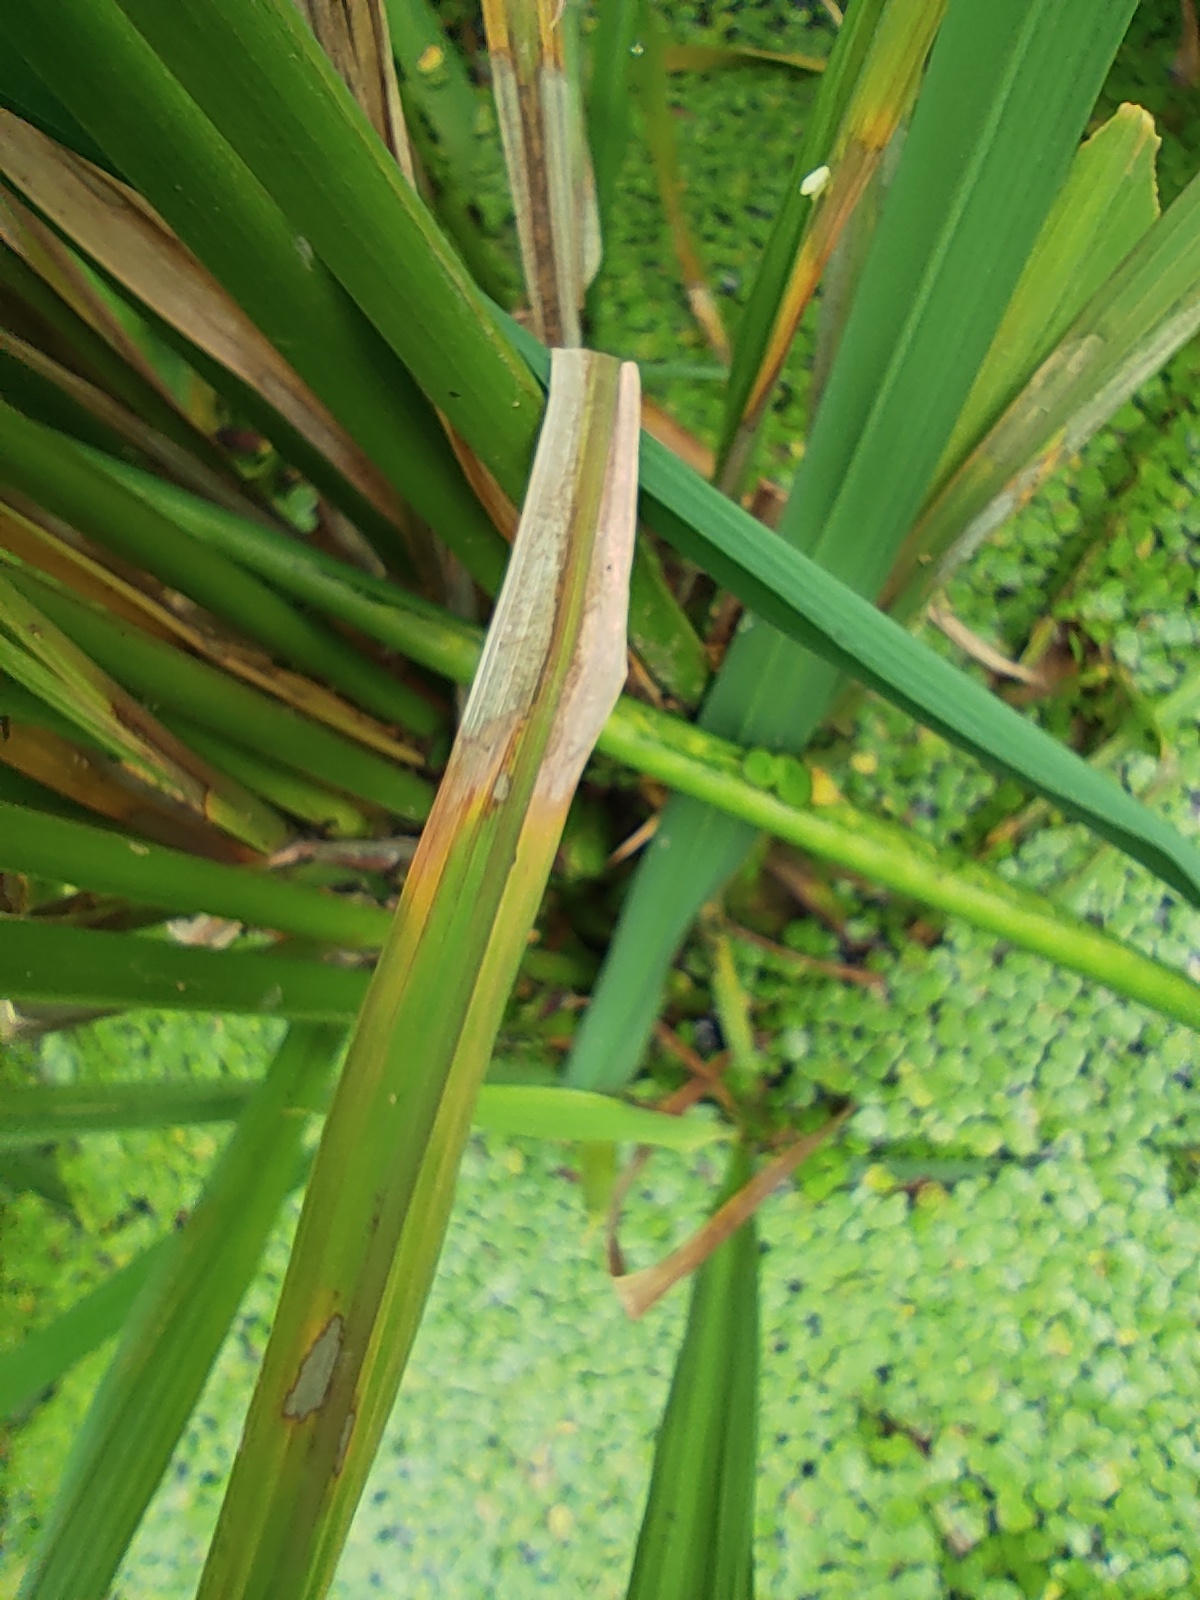

Brown Spot

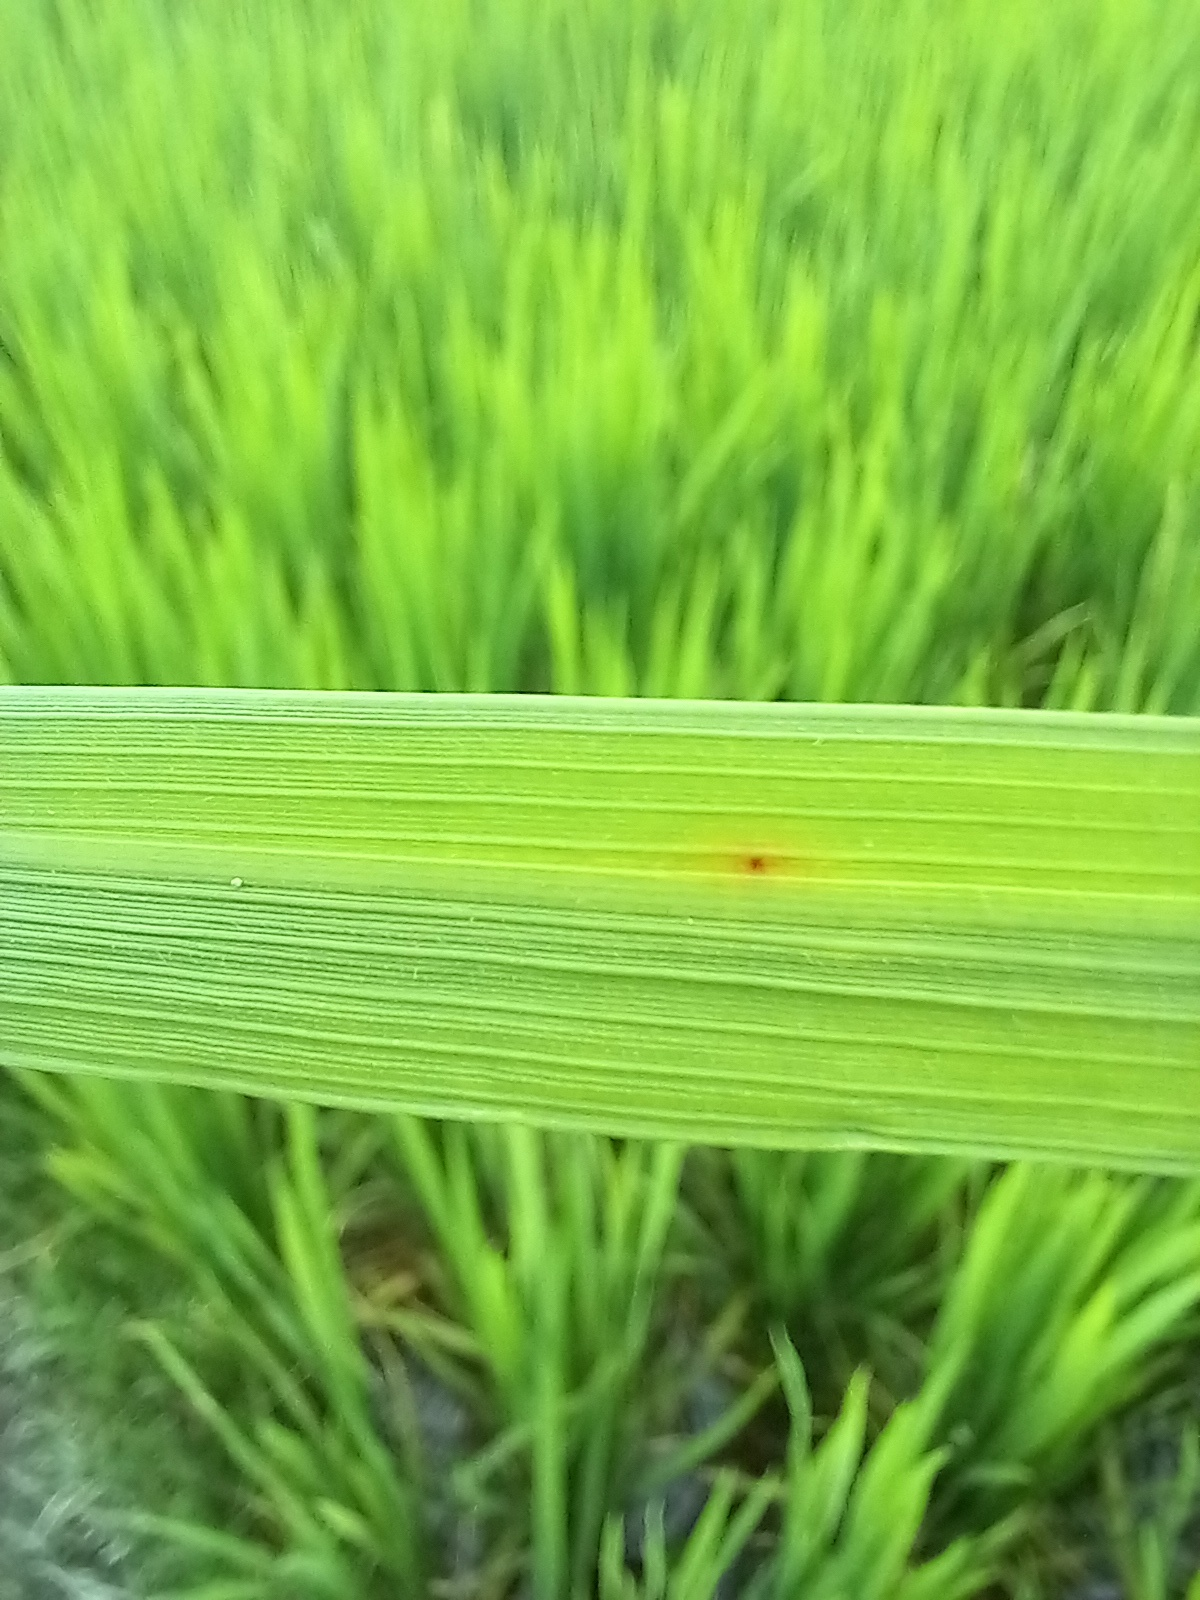

Healthy Rice Leaf

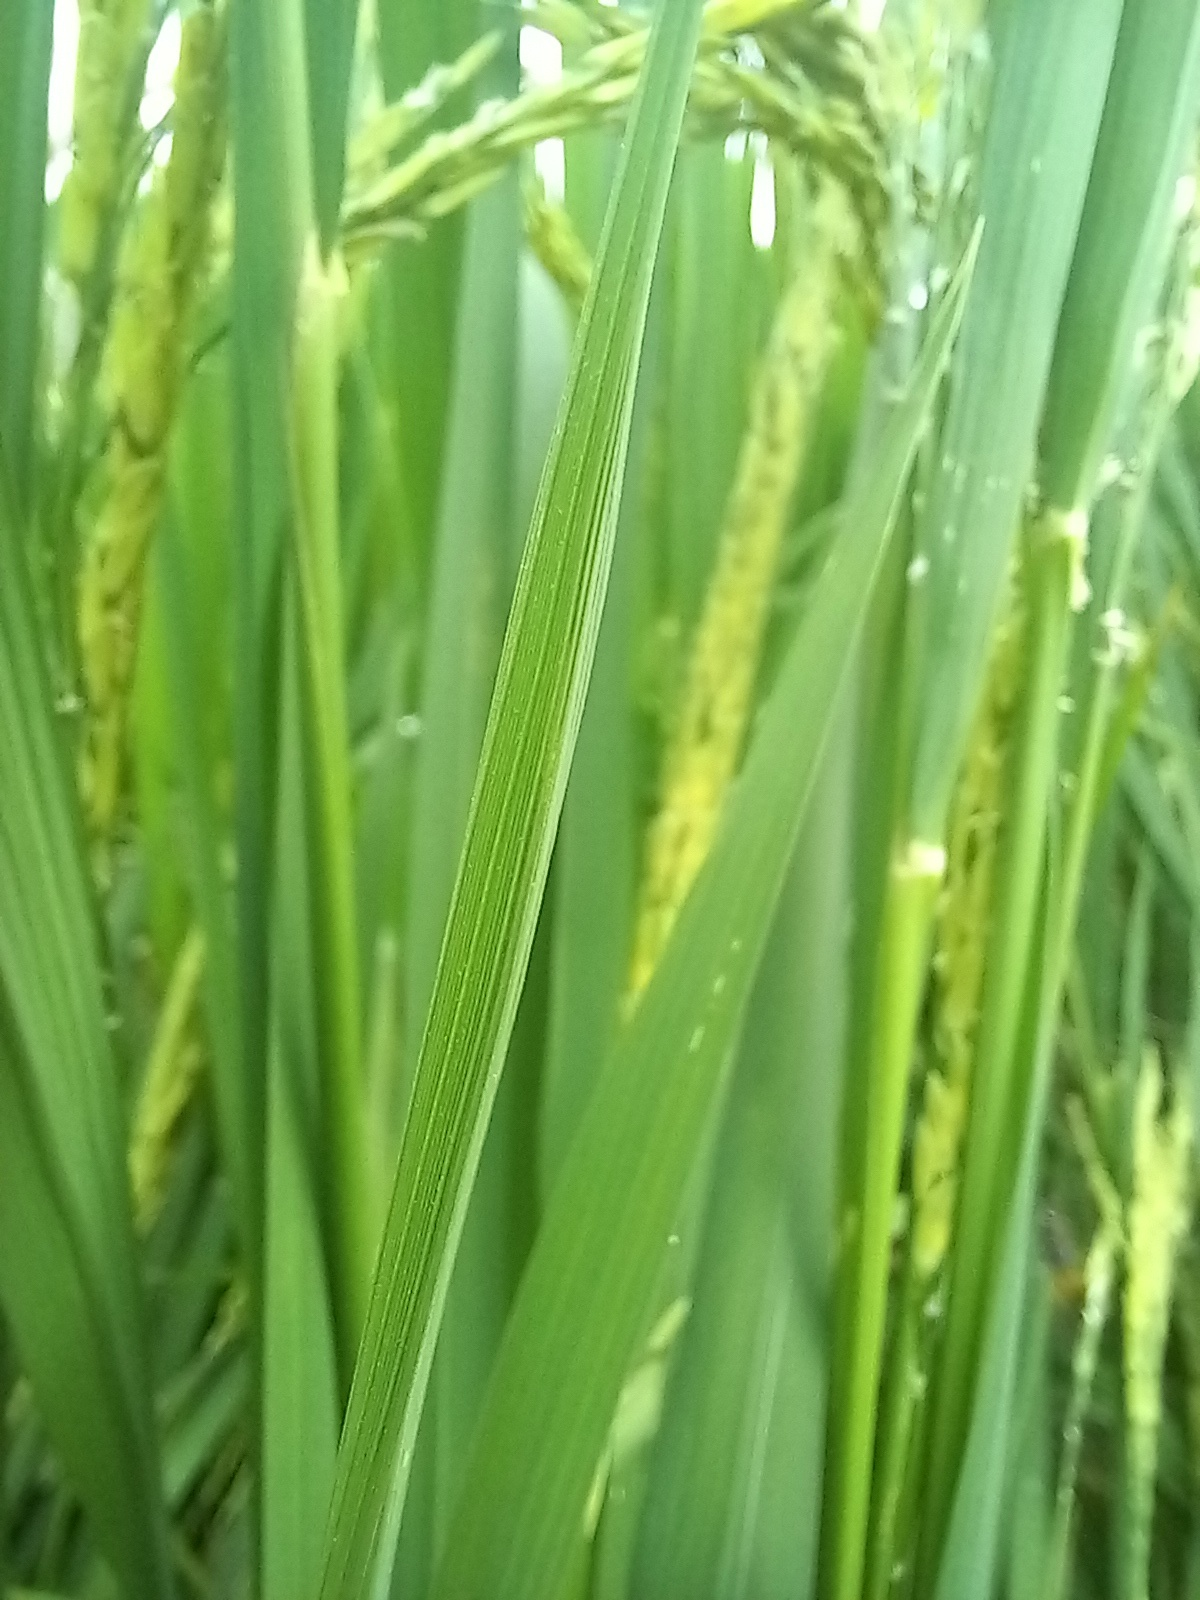

In [2]:
for a,b in [('fit','validation'),('fit','test'),('validation','test')]:
    assert not set(frame.loc[frame.cnn_split.eq(a),'similarity_group']) & set(frame.loc[frame.cnn_split.eq(b),'similarity_group'])
assert all((ROOT/p).is_file() for p in frame.path)
print('All dataset paths exist; similarity groups do not cross splits')
audit=pd.read_csv(ROOT/'data_audit/dataset_manifest.csv')
display(audit.groupby(['label','status']).size().rename('images').reset_index())
for label in CLASSES:
    display(Markdown(CLASSES[label][0]));display(Image(filename=str(EXAMPLES/f'{label}.jpg'),width=180))

## สกัดลักษณะและฝึก DenseNet121

เลือก CNN pretrained เพื่อเรียนรู้ลักษณะแผลและเนื้อสัมผัสจากภาพแทนฟีเจอร์สีที่กำหนดเอง ใช้ ImageNet, เปลี่ยนหัว 5 คลาส, RGB resize 256 → crop 224, normalize mean [0.485,0.456,0.406], std [0.229,0.224,0.225]

Train มี random crop/flip/rotation/color jitter/blur; validation/test ใช้ center crop ไม่สุ่ม ฝึกหัว 3 รอบ lr 0.001, fine-tune 12 รอบ lr 0.0001, AdamW, class weights, label smoothing 0.05. เลือก checkpoint ด้วย validation macro F1

โค้ดครบใน experiments/cnn5/common.py, train.py, evaluate.py. ฝึกใหม่ต้องติดตั้ง requirements-training.txt และ PyTorch สำหรับเครื่องนั้นก่อน

,phase,epoch,train_loss,validation_accuracy,validation_macro_f1,seconds
0,head,1,0.791456,0.803363,0.814960,63.707360
1,head,2,0.603056,0.861111,0.870161,38.228865
2,head,3,0.563088,0.878655,0.885210,37.423806
3,finetune,1,0.545104,0.903509,0.909581,67.808875
4,finetune,2,0.394715,0.970029,0.972444,63.749107
5,finetune,3,0.353238,0.972953,0.975434,64.710093
6,finetune,4,0.326724,0.961988,0.964892,64.488833
7,finetune,5,0.319793,0.976608,0.979621,63.657887
8,finetune,6,0.305617,0.979532,0.981173,64.030004
9,finetune,7,0.304393,0.981725,0.983571,64.923389


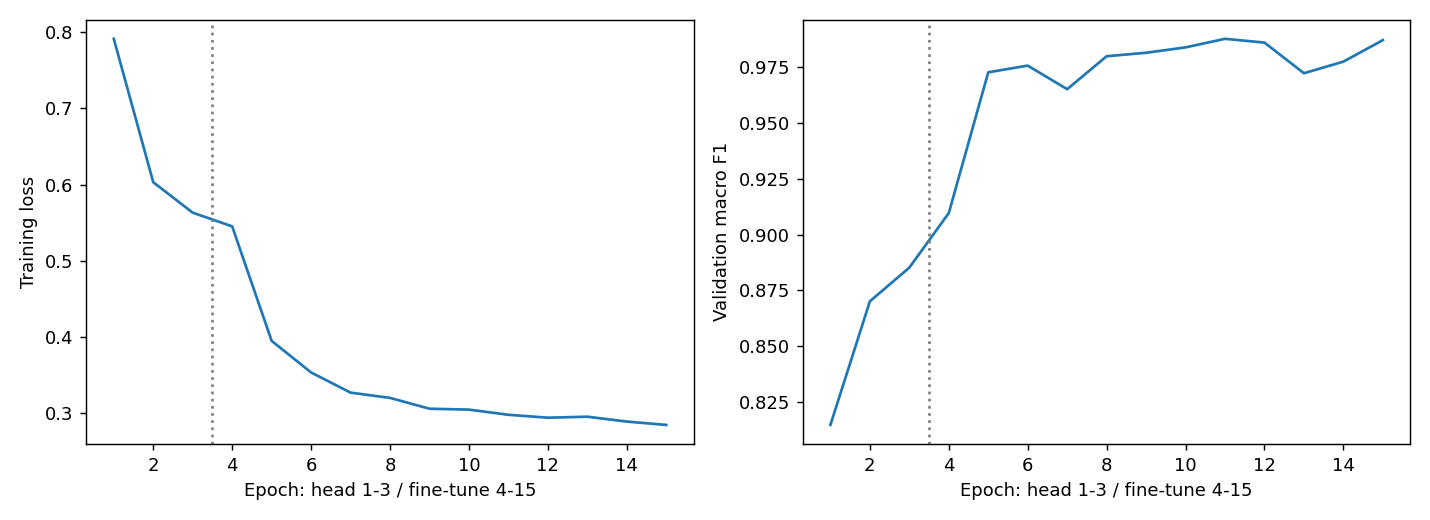

Selected checkpoint: {'phase': 'finetune', 'epoch': 8, 'train_loss': 0.2976340217574034, 'validation_accuracy': 0.9853801169590644, 'validation_macro_f1': 0.9874036490389029, 'seconds': 65.74775075912476}
Saved ONNX model: C:\Rice Leaf Diseases Detection\classification\rice_leaf_app\models\rice_cnn.onnx
Preprocessing: {'resize': [256, 256], 'crop_size': 224, 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'threshold': 0.5}


In [3]:
RETRAIN=False
if RETRAIN:
    import subprocess,os
    python=os.environ.get('CNN_PYTHON',sys.executable)
    for script in ['train.py','evaluate.py','report.py']:
        subprocess.run([python,str(P/script)],cwd=ROOT.parent,check=True)
display(pd.read_csv(P/'densenet121/history.csv'))
display(Image(filename=str(P/'training_curves.png')))
metadata=json.loads((ROOT/'rice_leaf_app/models/rice_cnn.json').read_text(encoding='utf-8'))
print('Selected checkpoint:',metadata['best_epoch'])
print('Saved ONNX model:',ROOT/'rice_leaf_app/models/rice_cnn.onnx')
print('Preprocessing:',{k:metadata[k] for k in ['resize','crop_size','mean','std','threshold']})

## ประเมิน test และความหมาย

คำนวณคะแนนใหม่จากผลทำนายที่โมเดลรันจริงและตรวจเทียบกับรายงาน Accuracy คือสัดส่วนถูก, macro F1 เฉลี่ยทุกคลาสเท่ากัน, weighted F1 ถ่วงตามจำนวนภาพ; recall บอกสัดส่วนภาพจริงของคลาสที่หาเจอ

CNN ตอบไม่แน่ใจเมื่อคะแนนต่ำกว่า 0.50 (เลือกจาก validation) และนับเป็นจำแนกไม่ถูกใน accuracy/recall หลัก SVM baseline เลือกคะแนนสูงสุด ไม่มีเกณฑ์ปฏิเสธ

In [4]:
pred=pd.read_csv(ARTIFACTS/'test_predictions.csv')
metrics=json.loads((ARTIFACTS/'metrics.json').read_text(encoding='utf-8'))
labels=list(CLASSES)
assert abs(accuracy_score(pred.label,pred.predicted)-metrics['accuracy'])<1e-12
assert abs(f1_score(pred.label,pred.predicted,labels=labels,average='macro')-metrics['macro_f1'])<1e-12
display(pd.Series({k:metrics[k] for k in ['accuracy','macro_f1','minimum_recall','minimum_recall_class']}))
display(pd.DataFrame(classification_report(pred.label,pred.predicted,labels=labels,output_dict=True,zero_division=0)).T)
display(pd.DataFrame(confusion_matrix(pred.label,pred.predicted,labels=labels+['uncertain'])[:5],index=labels,columns=labels+['uncertain']))
display(pd.read_csv(ARTIFACTS/'model_comparison.csv'))

accuracy                0.975763
macro_f1                0.981411
minimum_recall          0.966833
minimum_recall_class     healthy
dtype: object

,precision,recall,f1-score,support
rice_blast,0.951299,0.968595,0.959869,605.0
bacterial_leaf_blight,1.000000,1.000000,1.000000,318.0
sheath_blight,0.997126,0.983003,0.990014,353.0
brown_spot,0.997067,0.974212,0.985507,349.0
healthy,0.976549,0.966833,0.971667,603.0
micro avg,0.979279,0.975763,0.977518,2228.0
macro avg,0.984408,0.978528,0.981411,2228.0
weighted avg,0.979514,0.975763,0.977582,2228.0


,rice_blast,bacterial_leaf_blight,sheath_blight,brown_spot,healthy,uncertain
rice_blast,586,0,1,1,14,3
bacterial_leaf_blight,0,318,0,0,0,0
sheath_blight,4,0,347,0,0,2
brown_spot,7,0,0,340,0,2
healthy,19,0,0,0,583,1


,architecture,policy,accuracy,macro_f1,minimum_recall,coverage,rejected
0,densenet121,raw,0.976661,0.980786,0.966833,1.000000,0
1,densenet121,threshold,0.975763,0.981411,0.966833,0.996409,8
2,baseline_svm,raw,0.890036,0.903289,0.824363,1.000000,0


## ตัวอย่างผลทำนายและวิเคราะห์ข้อผิดพลาด

CNN raw accuracy 97.67% เทียบ SVM 89.00% บน split เดียวกัน; CNN เมื่อใช้เกณฑ์ accuracy 97.58%, recall ต่ำสุด 96.68%. CNN ยังสับสนระหว่าง Rice Blast และ Healthy เป็นหลัก ส่วน SVM recall ต่ำสุดเป็น Sheath Blight (82.44%). Bacterial Leaf Blight ที่ CNN ได้ 100% เป็นผลเฉพาะ test นี้ ไม่รับประกันภาพใหม่

คะแนนสูงยังไม่ยืนยันความทนพื้นหลังจริง ไม่มีชุดใบเดียวกันหลายพื้นหลังหรือ field IDs; การทดสอบภาพจริงถูกข้ามตามคำสั่ง

,label,predicted,images
0,brown_spot,rice_blast,7
1,brown_spot,uncertain,2
2,healthy,rice_blast,19
3,healthy,uncertain,1
4,rice_blast,brown_spot,1
5,rice_blast,healthy,14
6,rice_blast,sheath_blight,1
7,rice_blast,uncertain,3
8,sheath_blight,rice_blast,4
9,sheath_blight,uncertain,2


True: brown_spot; predicted: rice_blast

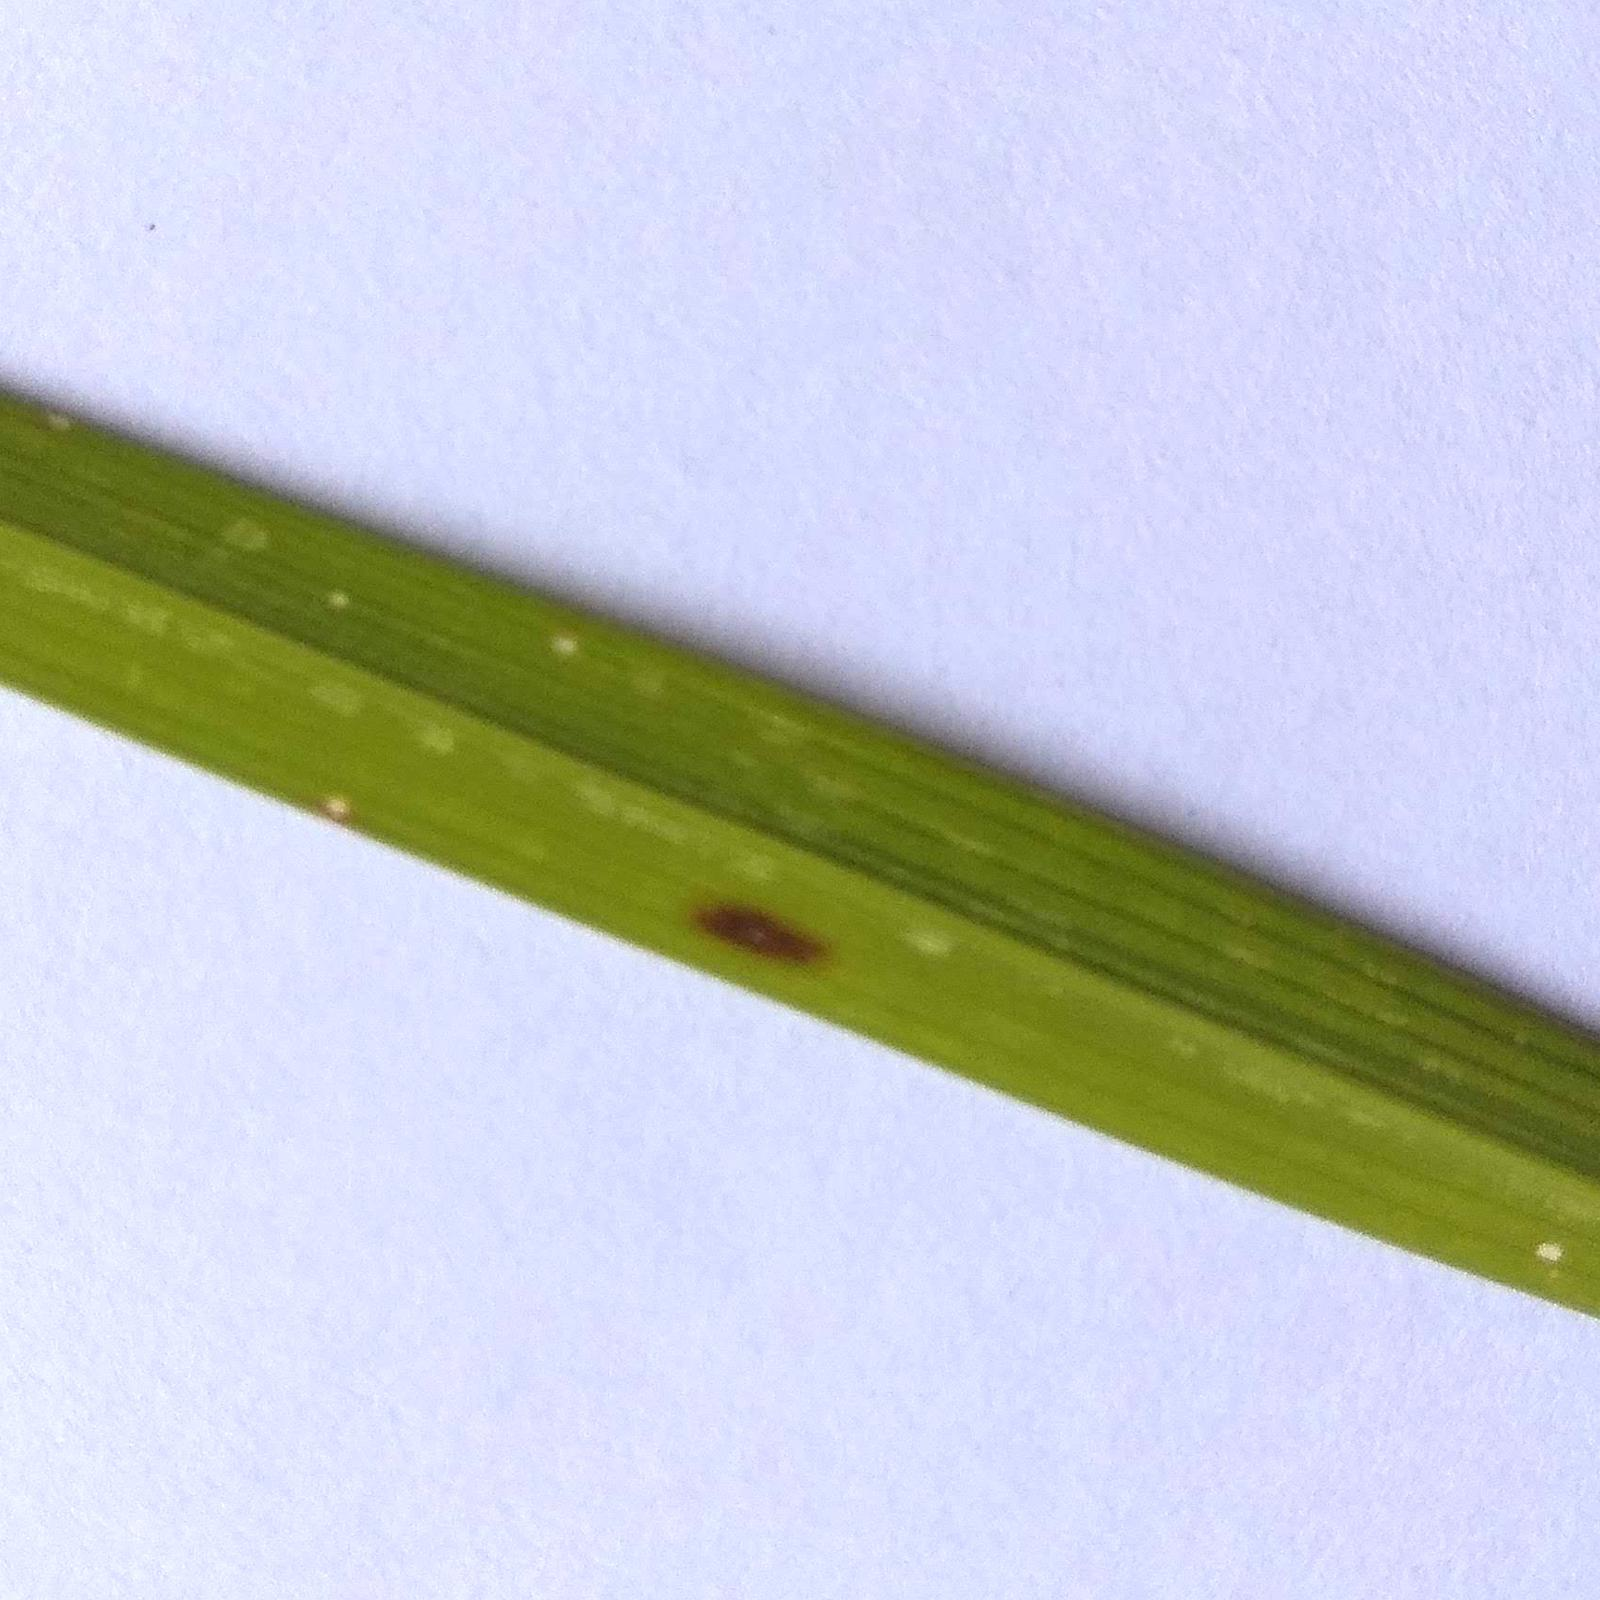

True: brown_spot; predicted: rice_blast

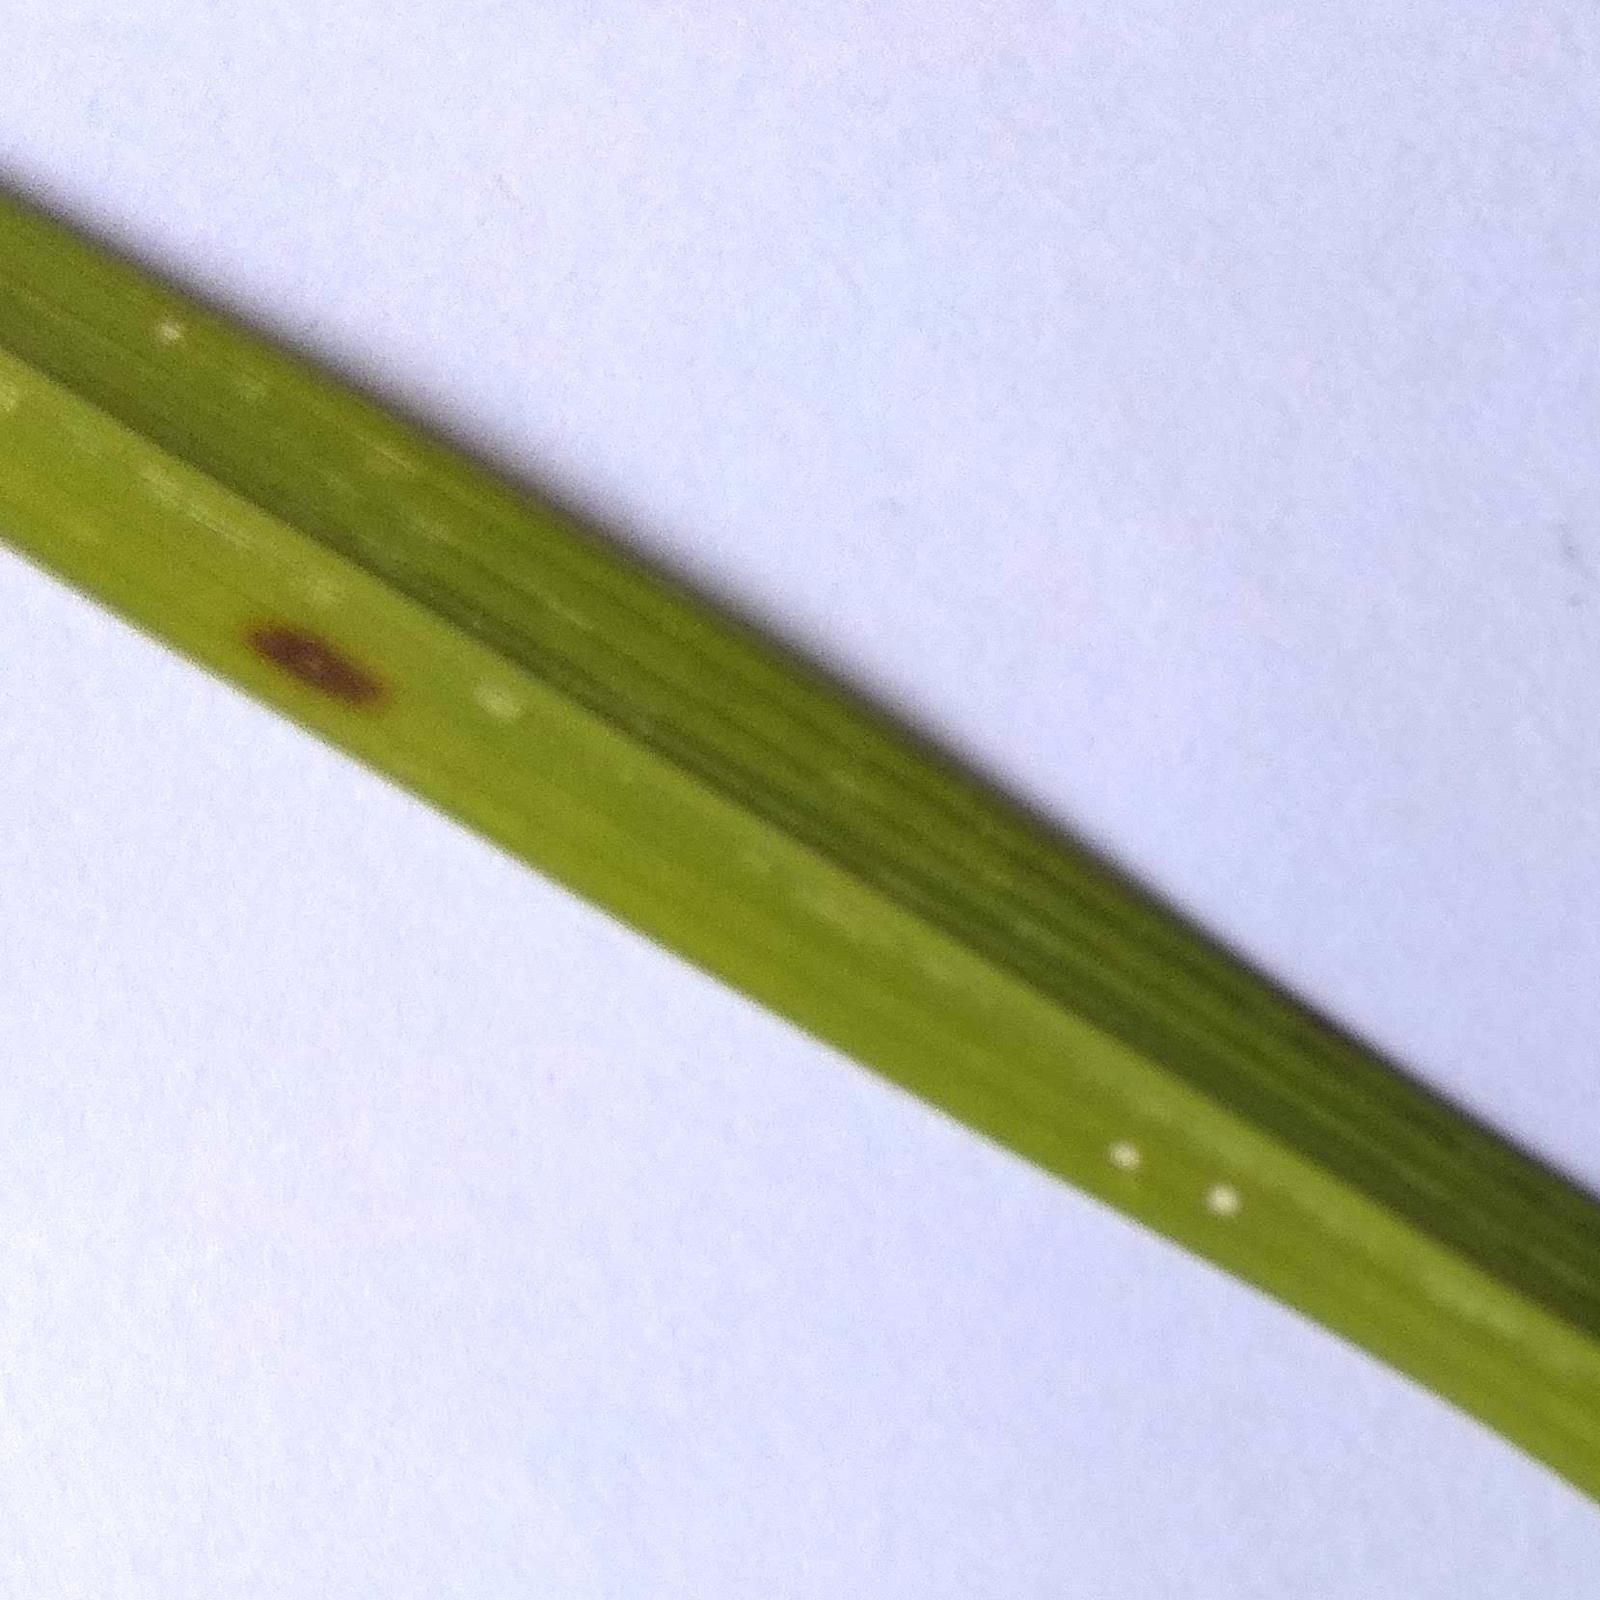

True: brown_spot; predicted: uncertain

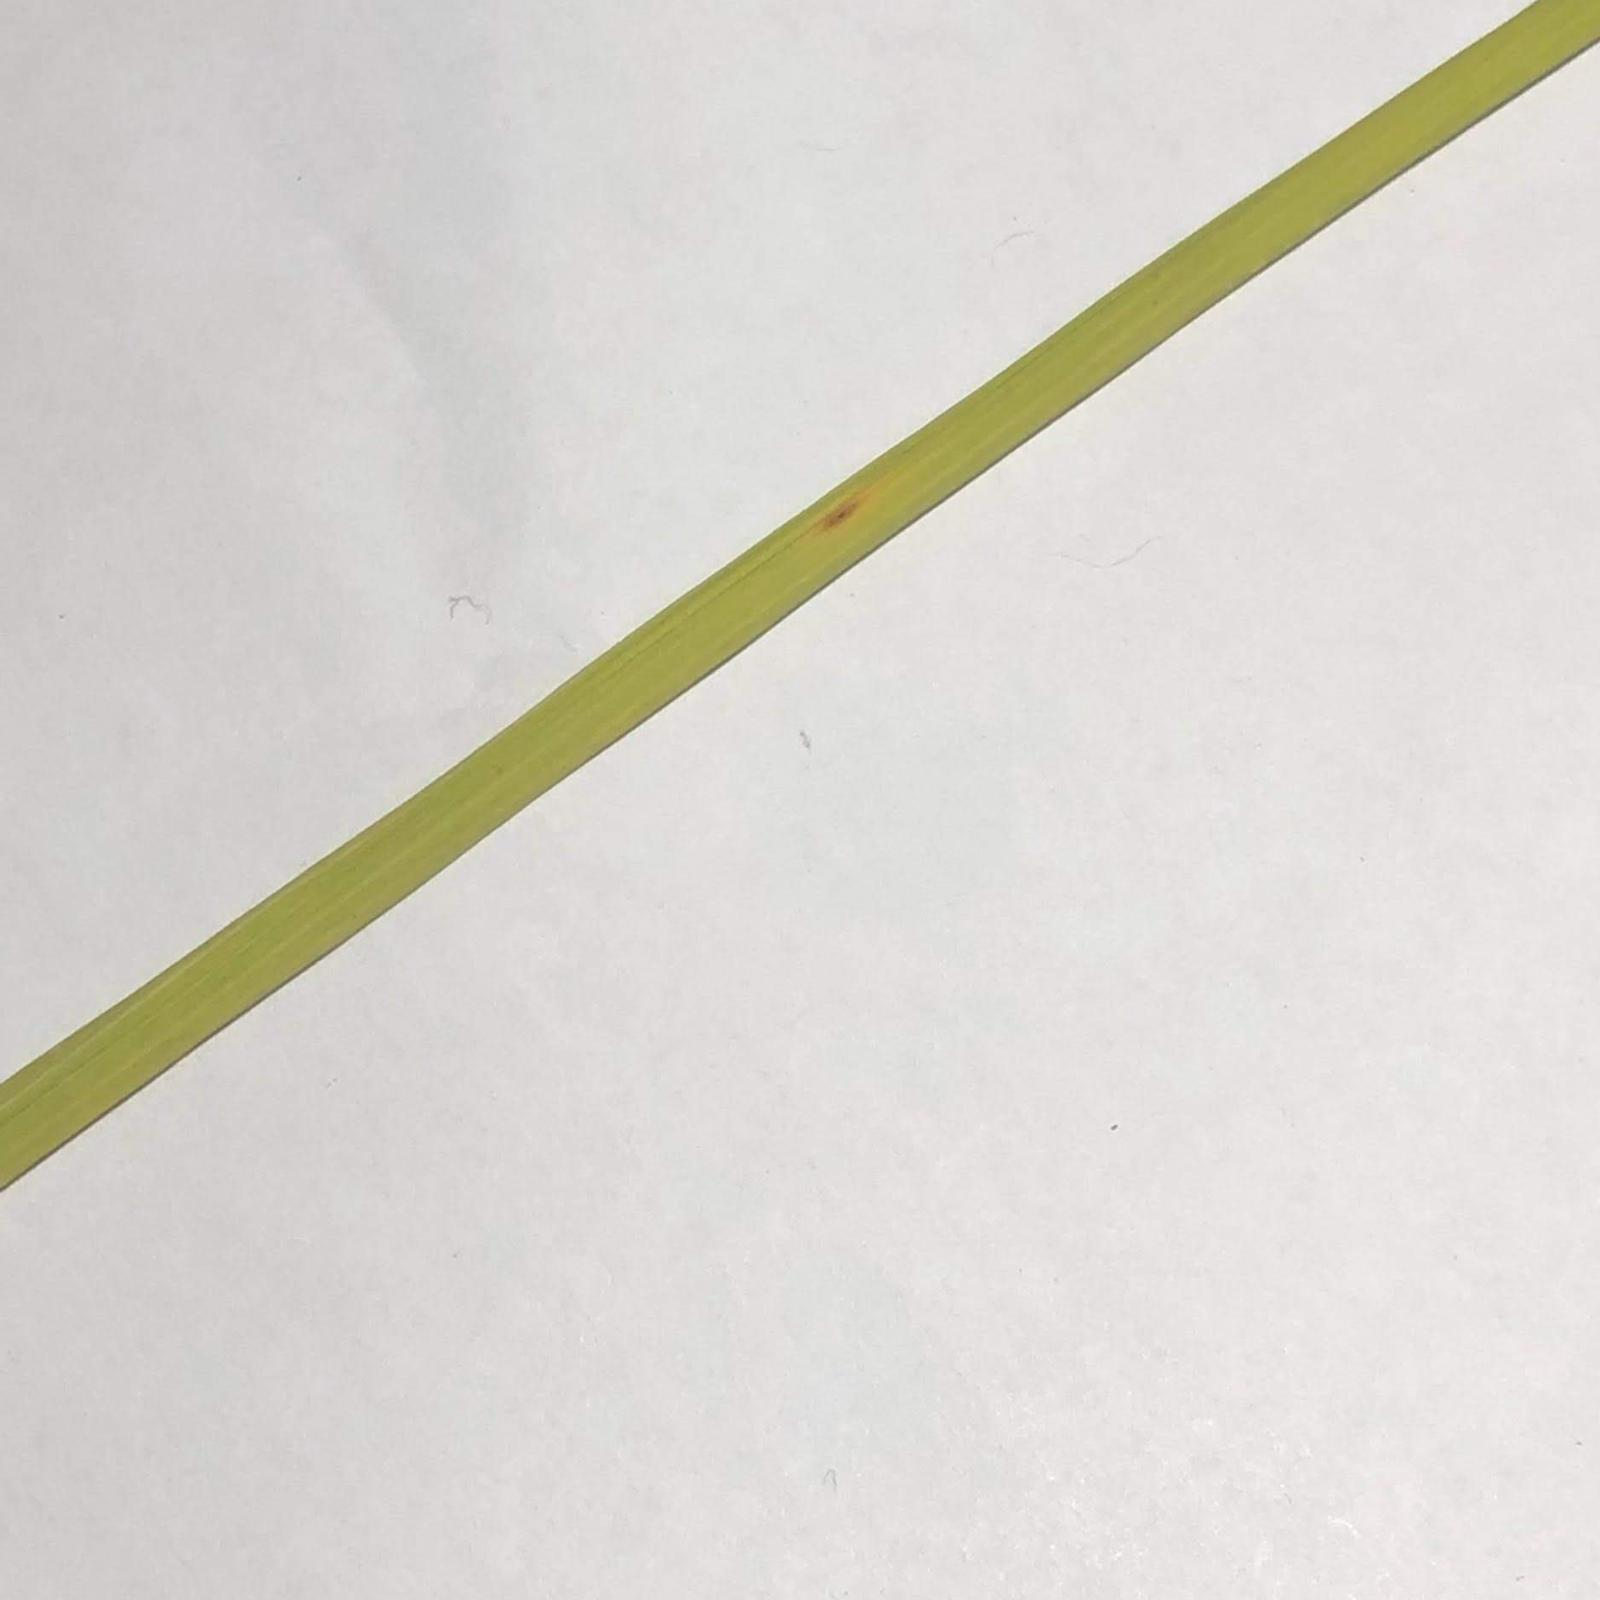

In [5]:
errors=pred[pred.label.ne(pred.predicted)]
display(errors.groupby(['label','predicted']).size().rename('images').reset_index())
for row in errors.head(3).itertuples():
    display(Markdown(f'True: {row.label}; predicted: {row.predicted}'))
    display(Image(filename=str(ROOT/row.path),width=220))

In [6]:
from rice_leaf_app.cnn_inference import get_predictor
model=get_predictor()
for label in CLASSES:
    scores,preview,summary,rows=model.predict(EXAMPLES/f'{label}.jpg')
    display(Markdown(f'True: {CLASSES[label][0]}'))
    display(Markdown(summary))
    display(pd.DataFrame(rows,columns=['Class','Score (%)']))

True: Rice Blast

### ผลจำแนก: Rice Blast · โรคไหม้
คะแนนโมเดล **89.2%**

คะแนนเป็นค่าประมาณจากโมเดล ไม่ใช่ความแน่นอนว่าภาพมีโรคนั้น

,Class,Score (%)
0,Rice Blast · โรคไหม้,89.19
1,Bacterial Leaf Blight · โรคขอบใบแห้ง,4.61
2,Healthy Rice Leaf · ใบข้าวปกติ,3.57
3,Sheath Blight · โรคกาบใบแห้ง,1.78
4,Brown Spot · โรคใบจุดสีน้ำตาล,0.85


True: Bacterial Leaf Blight

### ผลจำแนก: Bacterial Leaf Blight · โรคขอบใบแห้ง
คะแนนโมเดล **99.5%**

คะแนนเป็นค่าประมาณจากโมเดล ไม่ใช่ความแน่นอนว่าภาพมีโรคนั้น

...

### ผลจำแนก: Brown Spot · โรคใบจุดสีน้ำตาล
คะแนนโมเดล **71.8%**

คะแนนเป็นค่าประมาณจากโมเดล ไม่ใช่ความแน่นอนว่าภาพมีโรคนั้น

,Class,Score (%)
0,Brown Spot · โรคใบจุดสีน้ำตาล,71.82
1,Healthy Rice Leaf · ใบข้าวปกติ,17.79
2,Rice Blast · โรคไหม้,5.86
3,Sheath Blight · โรคกาบใบแห้ง,3.04
4,Bacterial Leaf Blight · โรคขอบใบแห้ง,1.49


True: Healthy Rice Leaf

### ผลจำแนก: Healthy Rice Leaf · ใบข้าวปกติ
คะแนนโมเดล **85.8%**

คะแนนเป็นค่าประมาณจากโมเดล ไม่ใช่ความแน่นอนว่าภาพมีโรคนั้น

,Class,Score (%)
0,Healthy Rice Leaf · ใบข้าวปกติ,85.78
1,Bacterial Leaf Blight · โรคขอบใบแห้ง,7.62
2,Rice Blast · โรคไหม้,3.89
3,Brown Spot · โรคใบจุดสีน้ำตาล,1.78
4,Sheath Blight · โรคกาบใบแห้ง,0.93


## การนำไปใช้

Gradio app ใช้ไฟล์โมเดลที่บันทึกและ preprocessing เดียวกับตอนฝึก เลือก CNN หรือ SVM ในหน้า Classification แล้วดูผลเปรียบเทียบใน Evaluation เปิดเว็บจากลิงก์ README ได้โดยไม่ต้องเปิดเครื่องนักศึกษา ตรวจสถานะการเผยแพร่จริงที่ STATUS.md

ข้อมูลโมเดล/ผลรายคลาส/ข้อจำกัดและหลักฐานใน experiments/cnn5/RESULTS.md